## Step 3: Issue Handling and Ticket Length Filtering

This notebook takes tickets which have already been cleaned, tokenized and lemmatized, and handles specific issues such as ticket IDs, customer names, dates and product codes, as well as filtering out very short tickets and truncating very long tickets.

In [2]:
import pandas as pd
import enchant
from collections import Counter
from langdetect import detect
import matplotlib.pyplot as plt

### Load cleaned and lemmatized tokens

In [3]:
df = pd.read_csv('/Users/annie/Masters/AI_and_TA/Coursework/Task4/tokenized_and_lemmatized_tickets_final.csv')
print(f'Loaded {len(df)} tickets.')
df.head()

Loaded 28120 tickets.


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,...,tag_6,tag_7,tag_8,clean_body,word_count_before,word_count_after_cleaning,tokens,processed_tokens,processed_text,word_count_after_t_and_l
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,...,NaN,NaN,NaN,i am writing to report a significant problem w...,82,80,"['writing', 'report', 'significant', 'problem'...","['write', 'report', 'significant', 'problem', ...",write report significant problem centralize ac...,37
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,...,NaN,NaN,NaN,i hope this message reaches you well i am reac...,76,74,"['reaches', 'reaching', 'request', 'detailed',...","['reach', 'request', 'detail', 'information', ...",reach request detail information capability sm...,31
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,...,NaN,NaN,NaN,i hope this message finds you well i am reachi...,91,81,"['finds', 'reaching', 'request', 'clarificatio...","['find', 'reach', 'request', 'clarification', ...",find reach request clarification bill payment ...,35
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,...,NaN,NaN,NaN,i hope this message reaches you well i am reac...,97,96,"['reaches', 'reaching', 'ask', 'compatibility'...","['reach', 'ask', 'compatibility', 'product', '...",reach ask compatibility product specific need ...,42
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51.0,Feature,Product,...,NaN,NaN,NaN,dear customer support i hope this message reac...,97,98,"['reaches', 'good', 'health', 'eager', 'learn'...","['reach', 'good', 'health', 'eager', 'learn', ...",reach good health eager learn feature product ...,39


In [4]:
# Load processed text column to assess obvious issues which need handling.
pd.set_option('display.max_colwidth', None)
df['processed_text']

0                                                  write report significant problem centralize account management portal currently appear offline outage block access setting lead substantial inconvenience attempt log multiple time use different browser device issue persist provide update status estimate resolution alternative way manage downtime
1                                                                              reach request detail information capability smart home integration product list website potential aim develop seamlessly interconnect environment essential understand interact various platform provide compatibility popular ecosystem amazon alexa google assistant apple
2                                                                          find reach request clarification bill payment procedure link account recently observe inconsistency charge apply like ensure fully understand cycle accept option potential extra firstly grateful provide detail explanation functio

### Handling Special Cases

In previous preprocessing steps, special characters ( including hyphens and numerical characters) have been removed. All text has also been converted to lower-case. This means that names, ticket IDs and product codes  have already been reduced to meaningless character sequences, making them harder to identify. Purely alphabetic sequences could survive the cleaning process, however manual inspection of tokens in the `processed_text` which aren't in the English Dictionary can help us reduce the effect on downstream analysis.

In [5]:
all_tokens = []
for text in df['processed_text'].dropna():
    all_tokens.extend(text.split())

en = enchant.Dict("en_GB")
us = enchant.Dict("en_US")
non_eng = []
non_eng_count = 0
counts = Counter(all_tokens)

for word, count in counts.most_common():
    if not en.check(word):
        if not us.check(word):
           non_eng.append((word, count))
           non_eng_count += count

print(f"Tokens not found in English dictionary:{non_eng_count}")
for word, count in non_eng:
    print(f" {word: <15} {count}")

print(f'Proportion of tokens not in English Dictionary:{non_eng_count/len(all_tokens)*100:.2f}%')

Tokens not found in English dictionary:18943
 saas            3106
 api             852
 microsoft       539
 crm             322
 clickup         304
 hipaa           274
 quickbooks      258
 postgresql      255
 elasticsearch   246
 erp             231
 apis            226
 misconfigured   205
 sql             203
 cyber           198
 redis           196
 jira            188
 misconfiguration 183
 zoho            180
 zapier          175
 smartsheet      174
 mysql           173
 airtable        172
 underperform    171
 kubernetes      169
 ibm             165
 seo             161
 ubuntu          150
 cassandra       147
 macbook         139
 mongodb         137
 macos           132
 nodejs          132
 matlab          129
 na              124
 salesforce      119
 hadoop          118
 misconfigurations 115
 malwarebytes    109
 hubspot         105
 wifi            99
 rapidminer      99
 aws             99
 norton          99
 kaspersky       99
 linux           97
 io         

In [6]:
uncommon_non_eng_tokens = 0
for words, count in non_eng:
    if count < 100:
        uncommon_non_eng_tokens += count
print(f'Total uncommon non-English tokens: {uncommon_non_eng_tokens}')

print(f'As proportion of all tokens:{uncommon_non_eng_tokens/sum(counts.values()):.2f}%')

Total uncommon non-English tokens: 7961
As proportion of all tokens:0.01%


Within the `non-eng` words, the most frequently appearing are company names and domain specific vocabulary, such as abbreviations. There is no evidence of consistent patterns of customer names, formatted ticket IDs, or product codes being left as tokens in the dataset. Many of the flagged words appear <100 times within the dataset, and calculating the sum of these as a proportion of all tokens shows that they will have minimal impact on clustering or topic modelling downstream. Those appearing more than 100 times can all be manually observed as company names and domain specific vocabulary, so should be retained, as they may be beneficial for gaining insights later in the project. As a result we will consider no special cases to have been found and will retain all `non-eng` tokens to avoid over-cleaning.

### Filtering by Ticket Length

In [7]:
# Identify tickets which are too short after cleaning
short_tickets = df['processed_text'].apply(lambda x: len(x.split()) <= 3)
print(f'Number of processed tickets with 3 words or fewer: {short_tickets.sum()} ')
print(f'Tokens removed: {df.loc[short_tickets,'word_count_after_t_and_l'].sum()}')
pd.set_option('display.max_colwidth', 50)
df[short_tickets]

Number of processed tickets with 3 words or fewer: 199 
Tokens removed: 515


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,...,tag_6,tag_7,tag_8,clean_body,word_count_before,word_count_after_cleaning,tokens,processed_tokens,processed_text,word_count_after_t_and_l
574,Incorporate NAS SaaS Solution,Can you offer comprehensive instructions?,Please facilitate a call at your convenience t...,Request,Customer Service,medium,en,52.0,Product,Feature,...,NaN,NaN,NaN,can you offer comprehensive instructions,5,5,"['offer', 'comprehensive', 'instructions']","['offer', 'comprehensive', 'instruction']",offer comprehensive instruction,3
747,Financial Institutions Investment Optimization...,Can you furnish details about your services?,We typically offer tailored investment strateg...,Request,Customer Service,low,en,52.0,Feature,Financial,...,NaN,NaN,NaN,can you furnish details about your services,7,7,"['furnish', 'details', 'services']","['furnish', 'detail', 'service']",furnish detail service,3
992,Issue Encountered,Assistance Needed,Kindly share more information,Problem,Technical Support,high,en,52.0,Bug,Support,...,NaN,NaN,NaN,assistance needed,2,2,"['assistance', 'needed']","['assistance', 'need']",assistance need,2
1002,Integration Assistance,Can you supply the integration instructions?,"<name>, thank you for contacting the service d...",Request,Customer Service,medium,en,52.0,Feature,Documentation,...,NaN,NaN,NaN,can you supply the integration instructions,6,6,"['supply', 'integration', 'instructions']","['supply', 'integration', 'instruction']",supply integration instruction,3
1182,Assistance with Digital Brand Expansion Tactics,Would you be able to share more information?,"<name>, thank you for your interest in digital...",Request,Customer Service,low,en,52.0,Strategy,Marketing,...,NaN,NaN,NaN,would you be able to share more information,8,8,"['able', 'share', 'information']","['able', 'share', 'information']",able share information,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27028,Project on Scalability Features,Request for detailed information,Will send a comprehensive email with informati...,Request,IT Support,medium,en,NaN,Feature,Documentation,...,NaN,NaN,NaN,request for detailed information,4,4,"['request', 'detailed', 'information']","['request', 'detail', 'information']",request detail information,3
27430,NaN,Seeking assistance with billing,Kindly provide your account number for billing...,Problem,Billing and Payments,medium,en,NaN,Billing,Payment,...,NaN,NaN,NaN,seeking assistance with billing,4,4,"['seeking', 'assistance', 'billing']","['seek', 'assistance', 'bill']",seek assistance bill,3
27921,Securing Medical Data in Hospital Settings,Please provide detailed solutions.,We can offer comprehensive solutions for secur...,Request,Sales and Pre-Sales,medium,en,NaN,Security,Documentation,...,NaN,NaN,NaN,please provide detailed solutions,4,4,"['provide', 'detailed', 'solutions']","['provide', 'detail', 'solution']",provide detail solution,3
28008,Improved Security for Medical Information,Need Assistance,We can assist with enhancing the security of y...,Change,General Inquiry,medium,en,NaN,Security,IT,...,NaN,NaN,NaN,need assistance,2,2,"['need', 'assistance']","['need', 'assistance']",need assistance,2


In [8]:
# Remove short tickets from dataset
df_filtered= df[~short_tickets].copy()
df = df_filtered.reset_index(drop=True)

print(f'Tickets of length <=3 have been removed: {len(df)} tickets remaining ')

Tickets of length <=3 have been removed: 27921 tickets remaining 


In [9]:
# Identify upper tickets length outliers
df['word_count_after_t_and_l'].describe()

count    27921.000000
mean        26.760288
std         12.345241
min          4.000000
25%         17.000000
50%         27.000000
75%         37.000000
max        107.000000
Name: word_count_after_t_and_l, dtype: float64

In [10]:
# Identify cutoff length
max_words = df['word_count_after_t_and_l'].quantile(0.99)
print(f'99th percentile word count of after preprocessing: {max_words}')

99th percentile word count of after preprocessing: 56.0


Number of tickets above 99th percentile:262
Proportion of tickets above 99th percentile:0.0094%


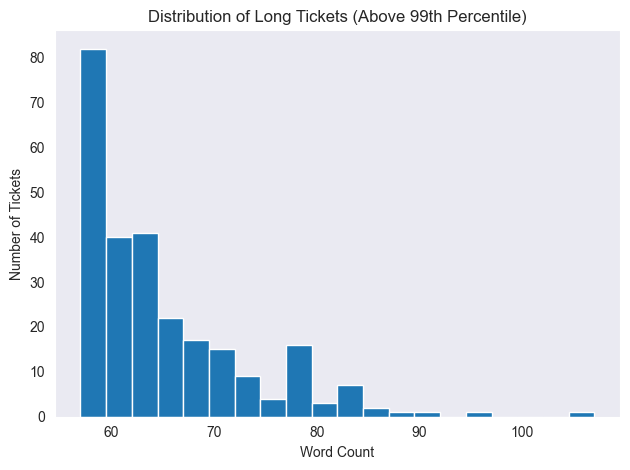

In [11]:
# Calculate proportion of tickets that exceed cutoff
above_cutoff = df[df['word_count_after_t_and_l'] > max_words]
print(f'Number of tickets above 99th percentile:{len(above_cutoff)}')
print(f'Proportion of tickets above 99th percentile:{len(above_cutoff)/len(df):.4f}%')

# Plot ticket distribution above cutoff
above_cutoff['word_count_after_t_and_l'].hist(bins=20)
plt.xlabel('Word Count')
plt.ylabel('Number of Tickets')
plt.title('Distribution of Long Tickets (Above 99th Percentile)')

plt.grid(False)
plt.tight_layout()
plt.show()

We can see that within those tickets above the 99th percentile cutoff, there is a clear sparsity of tickets over 85 words in length. It therefore makes sense to up the cutoff to 85 words (to not lose valuable data). Those tickets above 85 words can be truncated to not lose all information.

In [12]:
# Apply truncation
df['trunc_tokens'] = df['processed_text'].apply(lambda x: x.split()[:85])
df['trunc_processed_text'] = df['trunc_tokens'].apply(lambda x: ' '.join(x))

df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,...,tag_8,clean_body,word_count_before,word_count_after_cleaning,tokens,processed_tokens,processed_text,word_count_after_t_and_l,trunc_tokens,trunc_processed_text
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,...,NaN,i am writing to report a significant problem w...,82,80,"['writing', 'report', 'significant', 'problem'...","['write', 'report', 'significant', 'problem', ...",write report significant problem centralize ac...,37,"[write, report, significant, problem, centrali...",write report significant problem centralize ac...
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,...,NaN,i hope this message reaches you well i am reac...,76,74,"['reaches', 'reaching', 'request', 'detailed',...","['reach', 'request', 'detail', 'information', ...",reach request detail information capability sm...,31,"[reach, request, detail, information, capabili...",reach request detail information capability sm...
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,...,NaN,i hope this message finds you well i am reachi...,91,81,"['finds', 'reaching', 'request', 'clarificatio...","['find', 'reach', 'request', 'clarification', ...",find reach request clarification bill payment ...,35,"[find, reach, request, clarification, bill, pa...",find reach request clarification bill payment ...
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,...,NaN,i hope this message reaches you well i am reac...,97,96,"['reaches', 'reaching', 'ask', 'compatibility'...","['reach', 'ask', 'compatibility', 'product', '...",reach ask compatibility product specific need ...,42,"[reach, ask, compatibility, product, specific,...",reach ask compatibility product specific need ...
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51.0,Feature,Product,...,NaN,dear customer support i hope this message reac...,97,98,"['reaches', 'good', 'health', 'eager', 'learn'...","['reach', 'good', 'health', 'eager', 'learn', ...",reach good health eager learn feature product ...,39,"[reach, good, health, eager, learn, feature, p...",reach good health eager learn feature product ...


In [13]:
# Calculate Average Ticket Length
df['word_count_final'] = df['trunc_processed_text'].apply(lambda x: len(x.split()))
avg_word_count= (df['word_count_final'].sum())/len(df)
print(f'After preprocessing average ticket length is {avg_word_count:.2f} words.')

After preprocessing average ticket length is 26.76 words.


In [14]:
# Save tokenized and lemmatized data
df.to_csv('/Users/annie/Masters/AI_and_TA/Coursework/Task4/complete_preprocessing_final.csv', index=False)
print(f'Saved {len(df)} rows to complete_preprocessing_final.csv')

Saved 27921 rows to complete_preprocessing_final.csv


### Issue Handling and Length Filtering Summary
**Input:** `tokenized_and_lemmatized_tickets_final.csv`

**Output:** `complete_preprocessing_final.csv`

### Results:

| Metric                                                         | Value          |
|----------------------------------------------------------------|----------------|
| Total tickets before filtering                                 | 28,118         |
| Total tickets after filtering                                  | 27,921         |
| Avg words before filtering                                     | 26.59          |
| Avg words after filtering                                      | 26.76          |
| Max ticket length after filtering                              | 85.0           |
| Min ticket length after filtering                              | 4.0            |
| Tokens removed during filtering (Short tickets and Truncation) | 557.0 (0.074%) |